# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [53]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

# Load Data


In [54]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df.sort_values(by="fam", ascending=False, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref


DATA_PATH = "SILVER/sincFold_15_epochs_test_os_val20.csv"
df, df_ref = get_data(DATA_PATH)

display(df)
display(df_ref)

,fam,hc_100,hc_200,hc_400,rnadist_100,rnadist_200,rnadist_400,samples_100,samples_200,samples_400
8,tmRNA,0.273,0.310,0.267,0.251,0.299,0.283,0.229,0.262,0.290
7,telomerase,0.168,0.176,0.114,0.176,0.162,0.118,0.112,0.143,0.150
6,tRNA,0.526,0.564,0.588,0.582,0.525,0.540,0.568,0.551,0.596
5,srp,0.239,0.191,0.174,0.238,0.193,0.194,0.226,0.171,0.182
4,grp1,0.372,0.306,0.304,0.350,0.307,0.322,0.348,0.351,0.350
3,RNaseP,0.397,0.406,0.359,0.349,0.417,0.342,0.410,0.414,0.336
2,5s,0.290,0.424,0.308,0.232,0.391,0.314,0.369,0.301,0.320
1,23s,0.339,0.383,0.266,0.342,0.369,0.312,0.355,0.338,0.296
0,16s,0.312,0.304,0.309,0.304,0.281,0.291,0.329,0.310,0.300


,fam,famfold
8,tmRNA,0.302
7,telomerase,0.135
6,tRNA,0.562
5,srp,0.161
4,grp1,0.351
3,RNaseP,0.358
2,5s,0.360
1,23s,0.232
0,16s,0.305


In [55]:
df_ref.set_index("fam")["famfold"].to_dict()

{'tmRNA': 0.302,
 'telomerase': 0.135,
 'tRNA': 0.562,
 'srp': 0.161,
 'grp1': 0.351,
 'RNaseP': 0.358,
 '5s': 0.36,
 '23s': 0.232,
 '16s': 0.305}

In [56]:
def normalizar_y_melt(df, ref, experiments):
    ref_series = pd.Series(ref.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(ref_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [57]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})
s.to_csv("SILVER/sincFold_ovs_w_val_20_relf1.csv")
s

,modelo,rel_f1
0,hc_400,0.971075
1,rnadist_400,1.002313
2,samples_400,1.038485
3,samples_200,1.048353
4,rnadist_100,1.081777
5,samples_100,1.085875
6,rnadist_200,1.106708
7,hc_100,1.114146
8,hc_200,1.150147


In [58]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}

MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

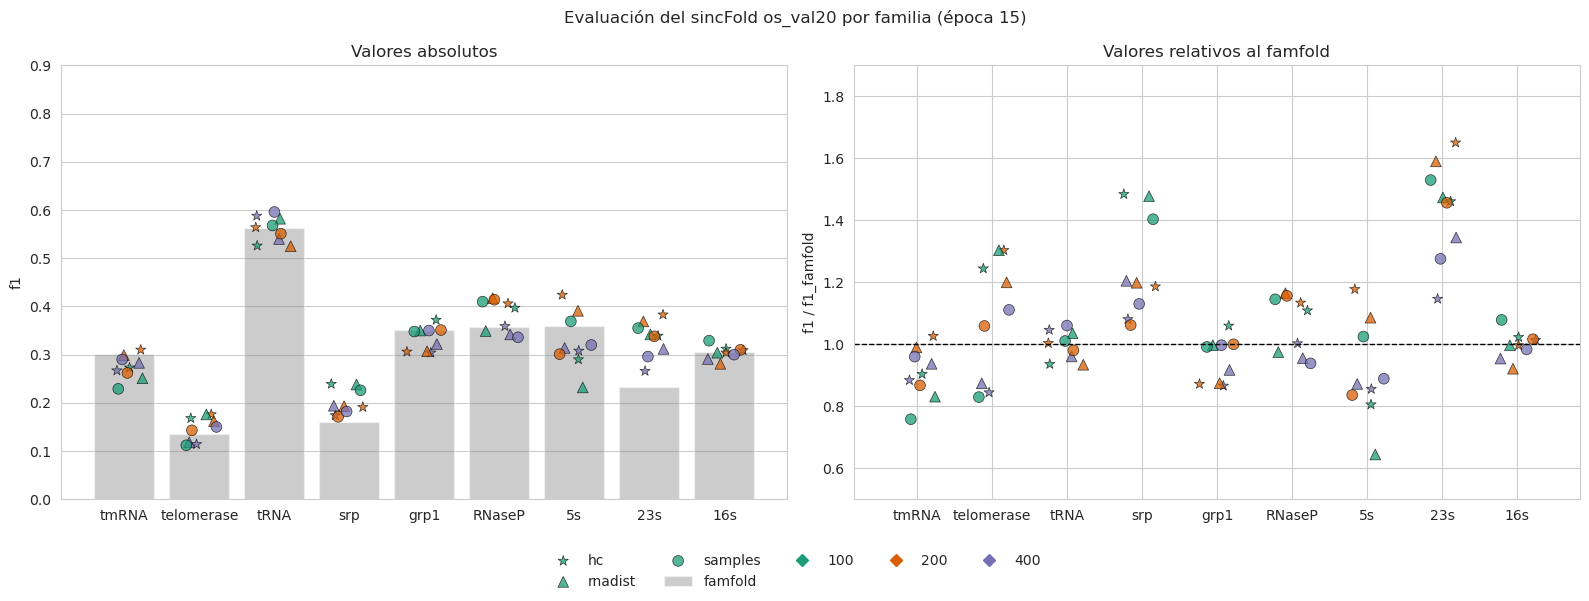

In [59]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del sincFold os_val20 por familia (época 15)")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [60]:
print(dfl)

           fam       modelo     f1   metodo umbral
0        tmRNA       hc_100  0.273       hc    100
1   telomerase       hc_100  0.168       hc    100
2         tRNA       hc_100  0.526       hc    100
3          srp       hc_100  0.239       hc    100
4         grp1       hc_100  0.372       hc    100
..         ...          ...    ...      ...    ...
76        grp1  samples_400  0.350  samples    400
77      RNaseP  samples_400  0.336  samples    400
78          5s  samples_400  0.320  samples    400
79         23s  samples_400  0.296  samples    400
80         16s  samples_400  0.300  samples    400

[81 rows x 5 columns]


In [ ]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del sincFold os_val20 por familia (época 15)")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()